In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
import tensorflow as tf
import itertools
import tensorflow.keras.applications as apps
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.data.experimental import AUTOTUNE
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import RandomRotation, RandomZoom
from tensorflow.keras.layers.experimental.preprocessing import Rescaling
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras import applications
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [23]:
# Extract the archive.zip file
def extract_zip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

In [24]:
# Paths
zip_path = '/content/archive.zip'  # Path to the archive.zip file65
extract_to = '/content/'  # Directory to extract the contents

# Extract the dataset
extract_zip(zip_path, extract_to)

In [25]:
BATCH_SIZE = 32
IMG_SIZE = (128, 128)
SEED = 0

In [26]:
tf.random.set_seed(SEED)

In [27]:
directory = '/content/Dataset'

In [28]:
train_dataset = image_dataset_from_directory(directory=directory,
                                             label_mode='categorical',
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE,
                                             shuffle=True,
                                             validation_split=0.2,
                                             subset='training',
                                             seed=SEED)


Found 6400 files belonging to 4 classes.
Using 5120 files for training.


In [29]:
full_validation_dataset = image_dataset_from_directory(directory=directory,
                                                       label_mode='categorical',
                                                       batch_size=BATCH_SIZE,
                                                       image_size=IMG_SIZE,
                                                       shuffle=True,
                                                       validation_split=0.2,
                                                       subset='validation',
                                                       seed=SEED)

Found 6400 files belonging to 4 classes.
Using 1280 files for validation.


In [30]:
validation_batches = len(full_validation_dataset)
print(f'Total number of full_validation_dataset batches : {validation_batches}')

validation_dataset = full_validation_dataset.take(validation_batches // 2)
test_dataset = full_validation_dataset.skip(validation_batches // 2)

print(f'Number of batches in validation dataset : {len(validation_dataset)}')
print(f'Number of batches in test dataset : {len(test_dataset)}')

Total number of full_validation_dataset batches : 40
Number of batches in validation dataset : 20
Number of batches in test dataset : 20


In [31]:
class_names = train_dataset.class_names
class_names

['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']

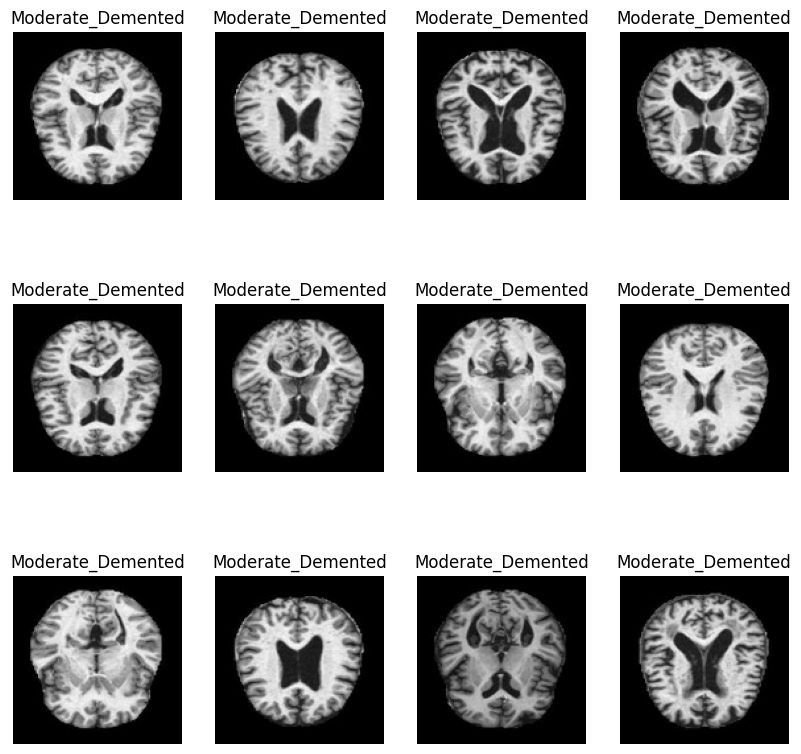

In [32]:
plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(max(labels[i]))])
        plt.axis('off')


In [33]:
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

In [34]:
def data_augmentar():
    """This function applies two data augmentation techniques.
        First, augmentation with RandomRotation.
        Second, augmentation with RandomZoom
    """

    data_augmentation = Sequential()
    data_augmentation.add(RandomRotation(factor=(-0.15, 0.15)))
    data_augmentation.add(RandomZoom((-0.3, -0.1)))

    return data_augmentation

In [35]:
data_augmentation = data_augmentar()
assert(data_augmentation.layers[0].name.startswith('random_rotation'))
assert(data_augmentation.layers[0].factor == (-0.15, 0.15))
assert(data_augmentation.layers[1].name.startswith('random_zoom'))
assert(data_augmentation.layers[1].height_factor == (-0.3, -0.1))

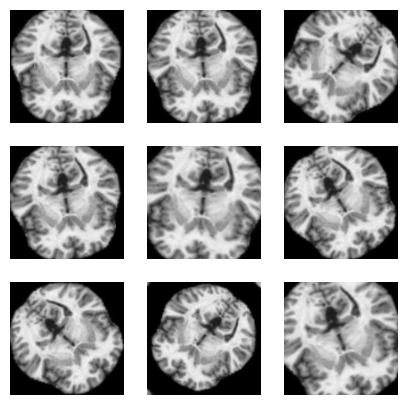

In [36]:
## applying data augmentation with a sample image.

plt.figure(figsize=(5, 5))
for images, labels in train_dataset.take(1):
    image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        augmented_image = data_augmentation(image)
        plt.imshow(augmented_image.numpy().astype('uint8'), cmap='gray')
        plt.axis('off')

In [37]:
## Calculate number of samples in each class.

class_counts = dict()
for folder in class_names:
    class_counts[folder] = len(os.listdir(directory+'/'+folder))

class_counts

{'Mild_Demented': 896,
 'Moderate_Demented': 64,
 'Non_Demented': 3200,
 'Very_Mild_Demented': 2240}

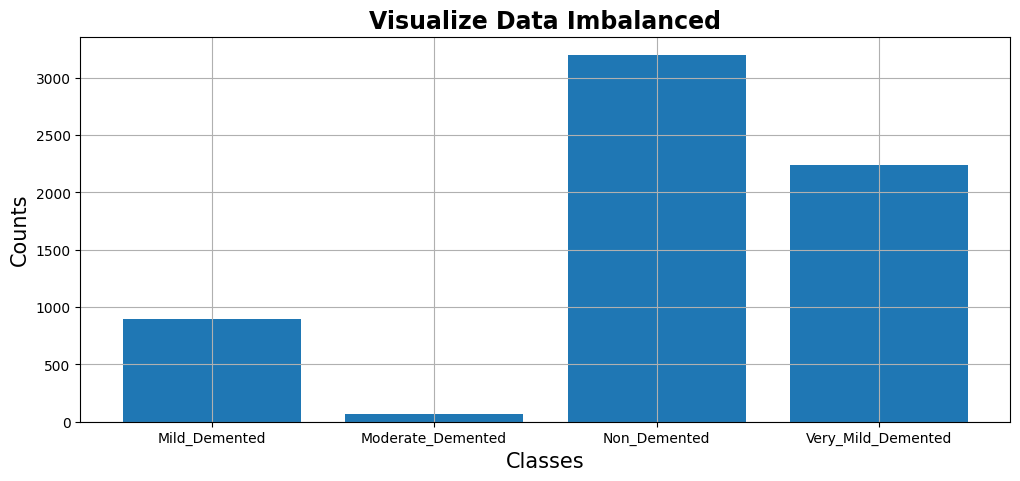

In [38]:
plt.figure(figsize=(12,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel('Classes', fontdict={'fontsize':15})
plt.ylabel('Counts', fontdict={'fontsize':15})
plt.title('Visualize Data Imbalanced', fontdict={'fontsize':17,
                                                 'fontweight':'bold'})
plt.grid(True)
plt.show()

In [39]:
## Calculate class weights.

total = sum(class_counts.values())
number_of_classes = len(class_counts)

class_weights = dict()
for i in range(number_of_classes):
    class_weights[i] = round(total / (number_of_classes * list(class_counts.values())[i]), 2)
    print(f'Weight for class \"{class_names[i]}\" : {class_weights[i]}')

Weight for class "Mild_Demented" : 1.79
Weight for class "Moderate_Demented" : 25.0
Weight for class "Non_Demented" : 0.5
Weight for class "Very_Mild_Demented" : 0.71


In [40]:
preprocess_input = applications.efficientnet.preprocess_input

In [41]:
model = applications.EfficientNetB0(include_top=False)
len(model.layers)

16705208/16705208 [==============================] - 0s 0us/step


238

In [42]:
def alzheimer_classifier(image_shape=IMG_SIZE, data_augmentation=data_augmentar()):
    """This function creates a classifier for Alzheimer disease MRI images.

    Arguments:
        image_shape-> the size of the image in the form (height, width).
        data_augmentation-> the data augmentation object to apply on the training data.

    Returns:
        model-> the created classifier.
    """
    IMG_SHAPE = image_shape + (3,)
    base_model = applications.EfficientNetB0(input_shape=IMG_SHAPE,
                                             include_top=False,
                                             weights='imagenet')

    base_model.trainable = True
    for layer in base_model.layers[0:218]:
        layer.trainable = False
    inputs = Input(shape=IMG_SHAPE)
    x = data_augmentation(inputs)
    x = preprocess_input(inputs)
    x = base_model(x)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(units=4, activation = "softmax")(x)

    model = Model(inputs, outputs)

    return model


In [43]:
alzheimer_model = alzheimer_classifier(IMG_SIZE, data_augmentation)

In [44]:
alzheimer_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 4, 4, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense_4 (Dense)             (None, 4)                 5124      
                                                                 
Total params: 4054695 (15.47 MB)
Trainable params: 1356084 (5.17 MB)
Non-trainable params: 2698611 (10.29 MB)
_________________________________________________________________


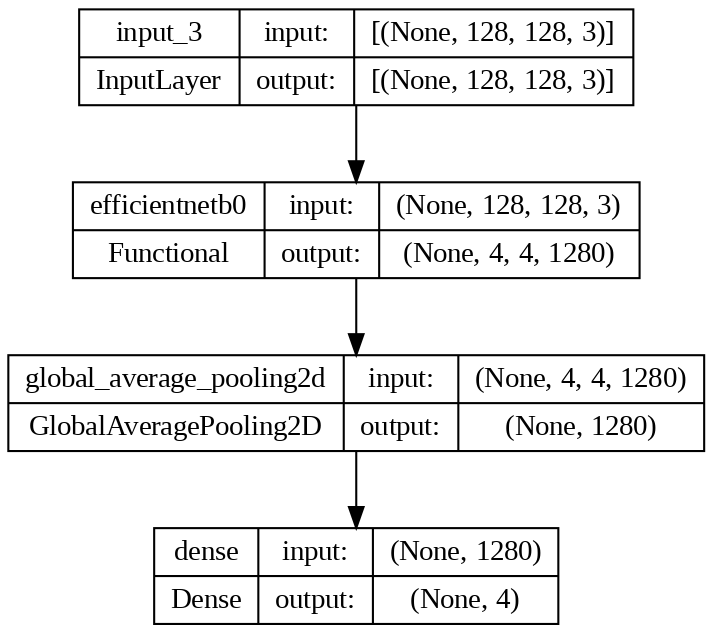

In [ ]:
tf.keras.utils.plot_model(alzheimer_model, show_shapes=True, dpi=150)

In [45]:
lr = 0.001
alzheimer_model.compile(loss=CategoricalCrossentropy(),
                        optimizer=Adam(learning_rate=lr),
                        metrics=['accuracy',
                                tf.keras.metrics.AUC(),
                                tf.keras.metrics.Precision(),
                                tf.keras.metrics.Recall(),])

In [46]:
# filepath = './effnet_best_weights.hdf5'
# Stop the model when accuracy is not improving
earlystopping = EarlyStopping(monitor = 'val_accuracy',
                              mode = 'max' ,
                              patience = 15,
                              verbose = 1)
# Finding point where accuracy differs more
# checkpoint    = ModelCheckpoint(filepath,
#                                 monitor = 'val_accuracy',
#                                 mode='max',
#                                 save_best_only=True,
#                                 verbose = 1)


callback_list = [earlystopping]

In [47]:
history = alzheimer_model.fit(train_dataset,
                              validation_data = validation_dataset,
                              epochs = 10,
                              class_weight=class_weights, callbacks = callback_list,
                              use_multiprocessing=True)

Epoch 1/10
160/160 [==============================] - 22s 53ms/step - loss: 1.1516 - accuracy: 0.4494 - auc: 0.7463 - precision_2: 0.5239 - recall_2: 0.2955 - val_loss: 0.8286 - val_accuracy: 0.6156 - val_auc: 0.8784 - val_precision_2: 0.6570 - val_recall_2: 0.5688
Epoch 2/10
160/160 [==============================] - 5s 32ms/step - loss: 0.7364 - accuracy: 0.5926 - auc: 0.8530 - precision_2: 0.6626 - recall_2: 0.4756 - val_loss: 0.7747 - val_accuracy: 0.6391 - val_auc: 0.8903 - val_precision_2: 0.6476 - val_recall_2: 0.6000
Epoch 3/10
160/160 [==============================] - 6s 36ms/step - loss: 0.6179 - accuracy: 0.6498 - auc: 0.8901 - precision_2: 0.7063 - recall_2: 0.5693 - val_loss: 0.7503 - val_accuracy: 0.6453 - val_auc: 0.8959 - val_precision_2: 0.6880 - val_recall_2: 0.5891
Epoch 4/10
160/160 [==============================] - 5s 32ms/step - loss: 0.5749 - accuracy: 0.6980 - auc: 0.9129 - precision_2: 0.7434 - recall_2: 0.6355 - val_loss: 0.7194 - val_accuracy: 0.6875 - val_

In [49]:
result = alzheimer_model.evaluate(test_dataset)
train_loss = result[0]
train_accuracy = result[1]
train_AUC = result[2]
train_pre = result[3]
train_rec = result[4]
print(f'Test Loss = {train_loss}')
print(f'Test Accuracy = {train_accuracy}')
print(f'Test Precision = {train_pre}')
print(f'Test Recall = {train_rec}')

20/20 [==============================] - 1s 28ms/step - loss: 0.2872 - accuracy: 0.8859 - auc: 0.9841 - precision_2: 0.8878 - recall_2: 0.8781
Test Loss = 0.287189781665802
Test Accuracy = 0.885937511920929
Test Precision = 0.887835681438446
Test Recall = 0.878125011920929


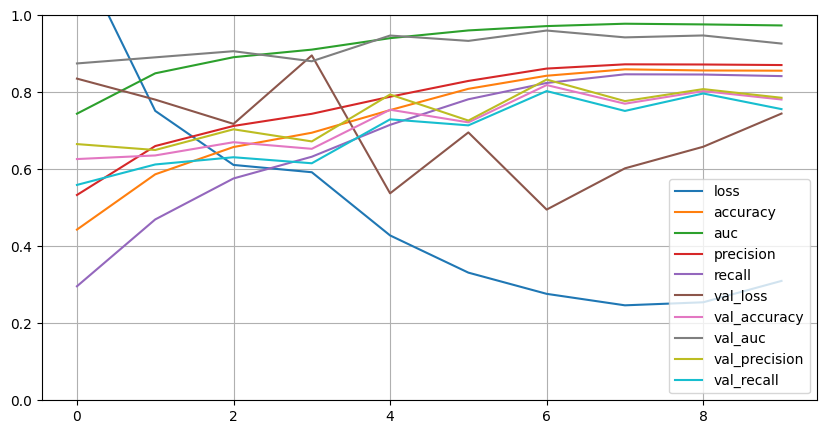

In [ ]:
pd.DataFrame(history.history).plot(figsize=(10,5))
plt.grid(True)
plt.gca().set_ylim(0,1)
plt.show()

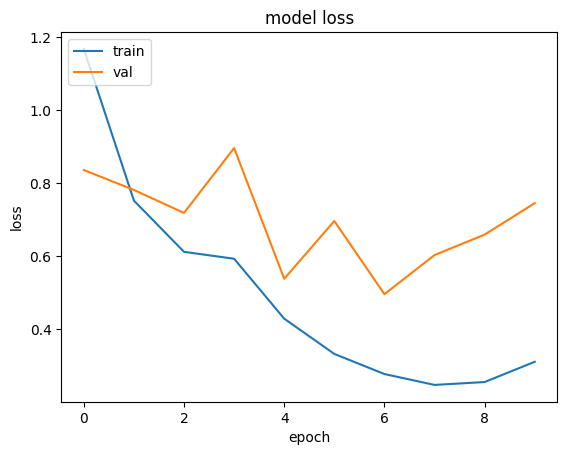

In [ ]:
# loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


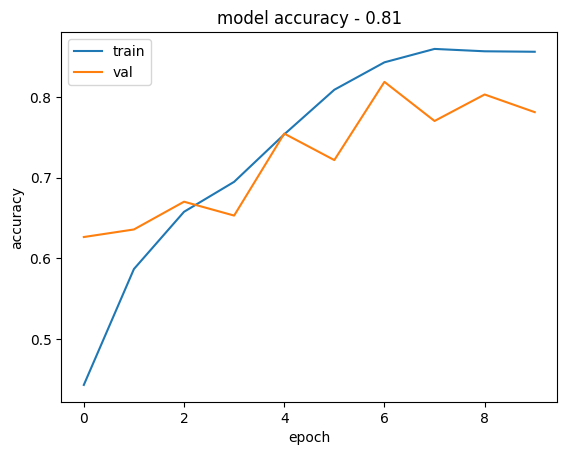

In [ ]:
#Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy - ' + str(format(result[1], "0.2f")))
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

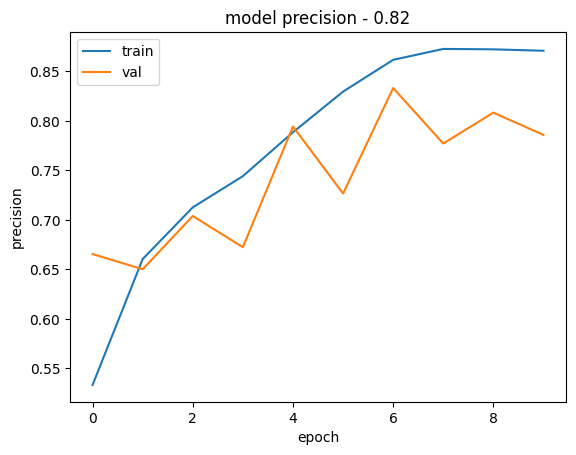

In [ ]:
#Precision
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('model precision - ' + str(format(result[3], "0.2f")))
plt.ylabel('precision')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

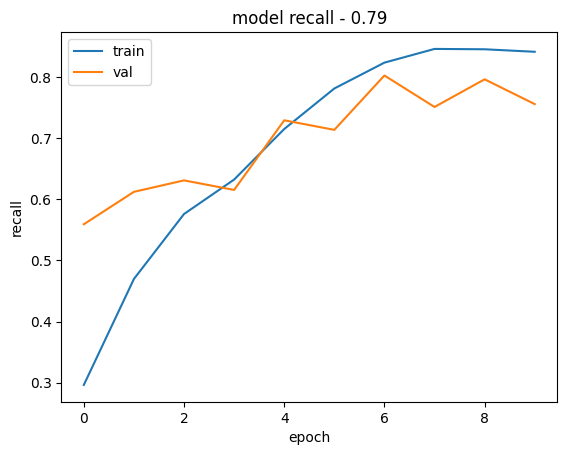

In [ ]:
#Recall
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('model recall - ' + str(format(result[4], "0.2f")))
plt.ylabel('recall')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

1/1 [==============================] - 0s 34ms/step


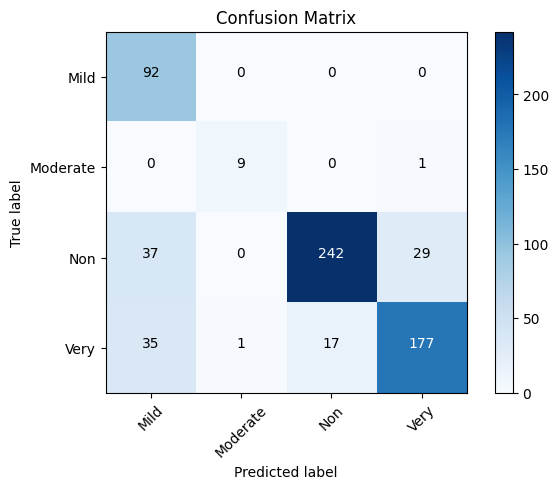

In [ ]:
from itertools import product
y_pred = []  # store predicted labels
y_true = []  # store true labels

# iterate over the dataset
for image_batch, label_batch in test_dataset:   # use dataset.unbatch() with repeat
   # append true labels
   y_true.append(label_batch)
   # compute predictions
   preds = alzheimer_model.predict(image_batch)
   # append predicted labels
   y_pred.append(np.argmax(preds, axis = 1))

# convert the true and predicted labels into tensors
correct_labels = tf.concat([item for item in y_true], axis = 0)
predicted_labels = tf.concat([item for item in y_pred], axis = 0)
correct_labels = np.argmax(correct_labels,axis=1)
confusion_mtx = confusion_matrix(correct_labels, predicted_labels)
# y_pred = alzheimer_model.predict(test_dataset)

# predicted_categories = tf.argmax(y_pred, axis=1)

# true_categories = tf.concat([y for x, y in test_dataset], axis=0)

# confusion_mtx = confusion_matrix(predicted_categories, true_categories)

# Define the class labels
class_names = ['Mild', 'Moderate', 'Non', 'Very']

# Plot the confusion matrix
plt.imshow(confusion_mtx, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
fmt = 'd'
thresh = confusion_mtx.max() / 2.
for i, j in product(range(confusion_mtx.shape[0]), range(confusion_mtx.shape[1])):
    plt.text(j, i, format(confusion_mtx[i, j], fmt),
             horizontalalignment="center",
             color="white" if confusion_mtx[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [4]:
def create_resnet101(image_size, num_classes):
    base_model = apps.ResNet101(include_top=False, weights='imagenet', input_shape=image_size)
    for layer in base_model.layers:
        layer.trainable = False
    model = models.Sequential()
    model.add(base_model)
    model.add(layers.GlobalMaxPooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    model.summary()
    visualization_path = 'resnet101_model_visualization.png'
    tf.keras.utils.plot_model(model, to_file=visualization_path, show_shapes=True, show_layer_names=True)
    print(f"Model visualization saved to {visualization_path}")
    return model

In [15]:
def create_resnet50(image_size, num_classes):
    base_model = apps.ResNet50(include_top=False, weights='imagenet', input_shape=image_size)
    for layer in base_model.layers:
        layer.trainable = False
    model = models.Sequential()
    model.add(base_model)
    model.add(layers.GlobalMaxPooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    model.summary()
    visualization_path = 'resnet50_model_visualization.png'
    tf.keras.utils.plot_model(model, to_file=visualization_path, show_shapes=True, show_layer_names=True)
    print(f"Model visualization saved to {visualization_path}")
    return model

In [16]:
# Image data generator with data augmentation
def create_image_data_generators(dataset_path, image_size, batch_size):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    train_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=image_size[:2],
        batch_size=batch_size,
        class_mode='categorical',
        subset='training'
    )
    validation_generator = train_datagen.flow_from_directory(
        dataset_path,
        target_size=image_size[:2],
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation'
    )
    return train_generator, validation_generator

In [17]:
# Example usage
dataset_path = '/content/Dataset'  # Path to the extracted dataset folder
image_size = (224, 224, 3)  # Replace with your image size
num_classes = 4  # Replace with the number of classes in your dataset
batch_size = 32

In [18]:
# Create data generators
train_generator, validation_generator = create_image_data_generators(dataset_path, image_size, batch_size)

Found 5121 images belonging to 4 classes.
Found 1279 images belonging to 4 classes.


In [8]:
# Create and train models
resnet101_model = create_resnet101(image_size, num_classes)

171446536/171446536 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101 (Functional)      (None, 7, 7, 2048)        42658176  
                                                                 
 global_max_pooling2d (Glob  (None, 2048)              0         
 alMaxPooling2D)                                                 
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dense_1 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 43183748 (164.73 MB)
Trainable params: 52

In [19]:
resnet50_model = create_resnet50(image_size, num_classes)

94765736/94765736 [==============================] - 0s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_max_pooling2d_1 (Gl  (None, 2048)              0         
 obalMaxPooling2D)                                               
                                                                 
 flatten_1 (Flatten)         (None, 2048)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               524544    
                                                                 
 dense_3 (Dense)             (None, 4)                 1028      
                                                                 
Total params: 24113284 (91.98 MB)
Trainable params: 525

In [20]:
# Training the models
epochs = 32

In [10]:
print("Training ResNet101 model...")
resnet101_model.fit(train_generator, validation_data=validation_generator, epochs=epochs)

Training ResNet101 model...
Epoch 1/10
161/161 [==============================] - 111s 614ms/step - loss: 1.3296 - accuracy: 0.4353 - precision: 0.4496 - recall: 0.3525 - val_loss: 1.1968 - val_accuracy: 0.3464 - val_precision: 0.3369 - val_recall: 0.3159
Epoch 2/10
161/161 [==============================] - 97s 602ms/step - loss: 1.1211 - accuracy: 0.4489 - precision: 0.4724 - recall: 0.3343 - val_loss: 1.2331 - val_accuracy: 0.3081 - val_precision: 0.2310 - val_recall: 0.1493
Epoch 3/10
161/161 [==============================] - 95s 588ms/step - loss: 1.0833 - accuracy: 0.4747 - precision: 0.5061 - recall: 0.3720 - val_loss: 1.0857 - val_accuracy: 0.4832 - val_precision: 0.5429 - val_recall: 0.2971
Epoch 4/10
161/161 [==============================] - 95s 589ms/step - loss: 1.0578 - accuracy: 0.4773 - precision: 0.5106 - recall: 0.3400 - val_loss: 1.1217 - val_accuracy: 0.3753 - val_precision: 0.2990 - val_recall: 0.1861
Epoch 5/10
161/161 [==============================] - 94s 586ms

In [11]:
# Evaluate the models
print("Evaluating ResNet101 model...")
resnet101_score = resnet101_model.evaluate(validation_generator)

Evaluating ResNet101 model...
40/40 [==============================] - 18s 456ms/step - loss: 1.0487 - accuracy: 0.5082 - precision: 0.6039 - recall: 0.3112


In [12]:
print(f"ResNet101 model accuracy: {resnet101_score[1]}, precision: {resnet101_score[2]}, recall: {resnet101_score[3]}")

ResNet101 model accuracy: 0.5082095265388489, precision: 0.6039453744888306, recall: 0.31118062138557434


In [48]:
model.save("ResNet101.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
